<a href="https://colab.research.google.com/github/ava-ly/ds-projects/blob/main/Project_SpaceX_Falcon_9_First_Stage_Landing_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SpaceX Falcon 9 First Stage Landing Prediction**

# 1. Collecting the Data

In this capstone project, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each. Much of these savings are because SpaceX can reuse the first stage. Therefore, if we can determine if the first stage will land, we can estimate the cost of a launch. This information can be valuable for companies wanting to bid against SpaceX for a rocket launch.

In this lab, you will collect Falcon 9 launch data from the SpaceX API, perform basic data wrangling, and ensure the data is in the correct format for subsequent analysis. The following is an example of a successful launch and landing:

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/lab_v2/images/landing_1.gif)

Several examples of an unsuccessful landing are shown here:

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/lab_v2/images/crash.gif)

Most unsuccessful landings are planned, where SpaceX performs a controlled landing in the ocean.

## Objectives

In this part of the project, we will:
1.  Request data from the SpaceX API.
2.  Clean and prepare the collected data for analysis.

## Import Libraries and Define Auxiliary Functions

We will import the following libraries for this lab.

In [ ]:
# Requests allows us to make HTTP requests which we will use to get data from an API
import requests
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Datetime is a library that allows us to represent dates
import datetime

# Setting this option will print all columns of a dataframe
pd.set_option('display.max_columns', None)
# Setting this option will print all of the data in a feature
pd.set_option('display.max_colwidth', None)

# Import plotting libraries (used in later sections, but good practice to import early)
import matplotlib.pyplot as plt
import seaborn as sns

Below, we define a series of helper functions. These functions will use the SpaceX API to extract specific information using identification numbers found in the launch data.

**Note:** These helper functions make live API calls. For true reproducibility of the entire data collection process from a specific point in time, all API responses would ideally be snapshotted. In this notebook, we use a static URL for the main launch list, but these helpers fetch details for specific IDs, which could change over time if the API is updated for those specific rocket/payload/core/launchpad entries.

In [ ]:
# Takes the dataset and uses the rocket column to call the API and append the booster name to the list
def getBoosterVersion(data):
    for x in data['rocket']:
        if x: # Check if x is not None or empty
            try:
                response = requests.get("https://api.spacexdata.com/v4/rockets/"+str(x))
                response.raise_for_status() # Raise an exception for bad status codes
                BoosterVersion.append(response.json()['name'])
            except requests.exceptions.RequestException as e:
                print(f"Error fetching booster version for {x}: {e}")
                BoosterVersion.append(None)
            except KeyError:
                print(f"'name' key not found in response for booster {x}")
                BoosterVersion.append(None)
        else:
            BoosterVersion.append(None)

From the <code>launchpad</code> ID, we want to retrieve the name of the launch site, its longitude, and latitude.

In [ ]:
# Takes the dataset and uses the launchpad column to call the API and append launch site info to the lists
def getLaunchSite(data):
    for x in data['launchpad']:
        if x: # Check if x is not None or empty
            try:
                response = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x))
                response.raise_for_status()
                json_response = response.json()
                Longitude.append(json_response['longitude'])
                Latitude.append(json_response['latitude'])
                LaunchSite.append(json_response['name'])
            except requests.exceptions.RequestException as e:
                print(f"Error fetching launch site for {x}: {e}")
                Longitude.append(None)
                Latitude.append(None)
                LaunchSite.append(None)
            except KeyError as e_key:
                print(f"Key {e_key} not found in response for launchpad {x}")
                Longitude.append(None)
                Latitude.append(None)
                LaunchSite.append(None)
        else:
            Longitude.append(None)
            Latitude.append(None)
            LaunchSite.append(None)

From the <code>payloads</code> ID, we want to retrieve the mass of the payload and its intended orbit.

In [ ]:
# Takes the dataset and uses the payloads column to call the API and append payload data to the lists
def getPayloadData(data):
    for load in data['payloads']:
        if load: # Check if load is not None or empty
            try:
                response = requests.get("https://api.spacexdata.com/v4/payloads/"+load)
                response.raise_for_status()
                json_response = response.json()
                PayloadMass.append(json_response['mass_kg'])
                Orbit.append(json_response['orbit'])
            except requests.exceptions.RequestException as e:
                print(f"Error fetching payload data for {load}: {e}")
                PayloadMass.append(None)
                Orbit.append(None)
            except KeyError as e_key:
                print(f"Key {e_key} not found in response for payload {load}")
                PayloadMass.append(None)
                Orbit.append(None)
        else:
            PayloadMass.append(None)
            Orbit.append(None)

From the <code>cores</code> array, we want to extract information about the first stage core used in the launch. This includes landing outcome, landing type, number of flights for that core, gridfin usage, reuse status, leg usage, landing pad, core block version, reuse count, and serial number.

In [ ]:
# Takes the dataset and uses the cores column to call the API and append core data to the lists
def getCoreData(data):
    for core_info in data['cores']:
        if core_info and core_info.get('core'): # Check if core_info and core_info['core'] are not None
            try:
                response = requests.get("https://api.spacexdata.com/v4/cores/"+core_info['core'])
                response.raise_for_status()
                json_response = response.json()
                Block.append(json_response.get('block'))
                ReusedCount.append(json_response.get('reuse_count'))
                Serial.append(json_response.get('serial'))
            except requests.exceptions.RequestException as e:
                print(f"Error fetching core data for {core_info['core']}: {e}")
                Block.append(None)
                ReusedCount.append(None)
                Serial.append(None)
            except KeyError as e_key:
                print(f"Key {e_key} not found in API response for core {core_info['core']}")
                Block.append(None)
                ReusedCount.append(None)
                Serial.append(None)
        else:
            Block.append(None)
            ReusedCount.append(None)
            Serial.append(None)

        # Extracting details from the core_info dictionary directly
        Outcome.append(str(core_info.get('landing_success', None)) + ' ' + str(core_info.get('landing_type', None)))
        Flights.append(core_info.get('flight', None))
        GridFins.append(core_info.get('gridfins', None))
        Reused.append(core_info.get('reused', None))
        Legs.append(core_info.get('legs', None))
        LandingPad.append(core_info.get('landpad', None))

Now, let's start requesting rocket launch data from the SpaceX API.

In [ ]:
spacex_url="https://api.spacexdata.com/v4/launches/past"

In [ ]:
response = requests.get(spacex_url)

Check the content of the response. For brevity, we'll only print the status code here. You can uncomment the `print(response.content)` line to see the full JSON response.

In [ ]:
# print(response.content) # Uncomment to see the full JSON response
print(f"Response Status Code: {response.status_code}")

Response Status Code: 200


### Task 1: Request and Parse SpaceX Launch Data

To ensure consistency and reproducibility for this project, we will use a static JSON response object hosted by IBM. This static file represents a snapshot of the SpaceX API's `/v4/launches/past` endpoint.

In [ ]:
static_json_url='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json'

We fetch this static JSON and check the response status code (should be 200 for success).

In [ ]:
static_response = requests.get(static_json_url)
print(f"Static JSON Response Status Code: {static_response.status_code}")

Static JSON Response Status Code: 200


Now, we decode the response content as JSON and convert it into a Pandas DataFrame using `json_normalize()` for easier manipulation.

In [ ]:
# Use json_normalize method to convert the JSON result into a DataFrame
data = pd.json_normalize(static_response.json())

Let's print the first 5 rows of the DataFrame to see its structure.

In [ ]:
# Display the head of the DataFrame
data.head()

,static_fire_date_utc,static_fire_date_unix,tbd,net,window,rocket,success,details,crew,ships,capsules,payloads,launchpad,auto_update,failures,flight_number,name,date_utc,date_unix,date_local,date_precision,upcoming,cores,id,fairings.reused,fairings.recovery_attempt,fairings.recovered,fairings.ships,links.patch.small,links.patch.large,links.reddit.campaign,links.reddit.launch,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Engine failure at 33 seconds and loss of vehicle,[],[],[],[5eb0e4b5b6c3bb0006eeb1e1],5e9e4502f5090995de566f86,True,"[{'time': 33, 'altitude': None, 'reason': 'merlin engine failure'}]",1,FalconSat,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cd9ffd86e000604b32a,False,False,False,[],https://images2.imgbox.com/3c/0e/T8iJcSN3_o.png,https://images2.imgbox.com/40/e3/GypSkayF_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,"Successful first stage burn and transition to second stage, maximum altitude 289 km, Premature engine shutdown at T+7 min 30 s, Failed to reach orbit, Failed to recover first stage",[],[],[],[5eb0e4b6b6c3bb0006eeb1e2],5e9e4502f5090995de566f86,True,"[{'time': 301, 'altitude': 289, 'reason': 'harmonic oscillation leading to premature engine shutdown'}]",2,DemoSat,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdaffd86e000604b32b,False,False,False,[],https://images2.imgbox.com/4f/e3/I0lkuJ2e_o.png,https://images2.imgbox.com/be/e7/iNqsqVYM_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-rocket-fails-reach-orbit.html,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Residual stage 1 thrust led to collision between stage 1 and stage 2,[],[],[],"[5eb0e4b6b6c3bb0006eeb1e3, 5eb0e4b6b6c3bb0006eeb1e4]",5e9e4502f5090995de566f86,True,"[{'time': 140, 'altitude': 35, 'reason': 'residual stage-1 thrust led to collision between stage 1 and stage 2'}]",3,Trailblazer,2008-08-03T03:34:00.000Z,1217734440,2008-08-03T15:34:00+12:00,hour,False,"[{'core': '5e9e289ef3591814873b2625', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdbffd86e000604b32c,False,False,False,[],https://images2.imgbox.com/3d/86/cnu0pan8_o.png,https://images2.imgbox.com/4b/bd/d8UxLh4q_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1-flight-3-mission-summary,https://en.wikipedia.org/wiki/Trailblazer_(satellite),NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,True,"Ratsat was carried to orbit on the first successful orbital launch of any privately funded and developed, liquid-propelled carrier rocket, the SpaceX Falcon 1",[],[],[],[5eb0e4b7b6c3bb0006eeb1e5],5e9e4502f5090995de566f86,True,[],4,RatSat,2008-09-28T23:15:00.000Z,1222643700,2008-09-28T11:15:00+12:00,hour,False,"[{'core': '5e9e289ef3591855dc3b2626', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_succes

You'll notice that many columns contain IDs (e.g., `rocket`, `payloads`, `launchpad`, `cores`). These IDs refer to other entities in the SpaceX API. We will use our helper functions to fetch more detailed information for these entities.

First, let's subset our DataFrame, keeping only the features relevant for fetching more details, along with `flight_number` and `date_utc`.

In [ ]:
# Subset the DataFrame to relevant columns
data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]

# We will remove rows with multiple cores or multiple payloads in a single rocket.
# These are typically Falcon Heavy launches or missions with complex payload configurations,
# which are out of scope for this Falcon 9 first-stage prediction.
data = data[data['cores'].map(len)==1]
data = data[data['payloads'].map(len)==1]

# Since 'payloads' and 'cores' are now lists of size 1, extract the single dictionary/value from each list.
data.loc[:, 'cores'] = data['cores'].map(lambda x : x[0])
data.loc[:, 'payloads'] = data['payloads'].map(lambda x : x[0])

# Convert 'date_utc' to datetime objects and then extract just the date part.
data.loc[:, 'date'] = pd.to_datetime(data['date_utc']).dt.date

# Filter the data to include launches up to November 13, 2020.
data = data[data['date'] <= datetime.date(2020, 11, 13)]

The goal is to enrich our dataset with specific details:
*   From `rocket` ID: Booster name.
*   From `payloads` ID: Payload mass and orbit.
*   From `launchpad` ID: Launch site name, longitude, and latitude.
*   From `cores` data: Landing outcome, landing type, flight count for the core, gridfin/leg usage, reuse status, landing pad, core block, reuse count, and serial number.

The data from these API calls (made by our helper functions) will be stored in lists and then used to create a new, more detailed DataFrame.

In [ ]:
# Initialize global lists to store fetched data.
# (Note: Using global variables is generally discouraged for larger projects, but acceptable for this script's flow.)
BoosterVersion = []
PayloadMass = []
Orbit = []
LaunchSite = []
Outcome = []
Flights = []
GridFins = []
Reused = []
Legs = []
LandingPad = []
Block = []
ReusedCount = []
Serial = []
Longitude = []
Latitude = []

Now, we call the helper functions to populate these lists using the IDs from our `data` DataFrame.

In [ ]:
# Call the helper functions to populate the global lists
getBoosterVersion(data)
getLaunchSite(data)
getPayloadData(data)
getCoreData(data)

Finally, we construct our enriched dataset. We combine the newly populated lists and relevant columns from the original `data` DataFrame into a dictionary.

In [ ]:
launch_dict = {
    'FlightNumber': list(data['flight_number']),
    'Date': list(data['date']),
    'BoosterVersion': BoosterVersion,
    'PayloadMass': PayloadMass,
    'Orbit': Orbit,
    'LaunchSite': LaunchSite,
    'Outcome': Outcome,
    'Flights': Flights,
    'GridFins': GridFins,
    'Reused': Reused,
    'Legs': Legs,
    'LandingPad': LandingPad,
    'Block': Block,
    'ReusedCount': ReusedCount,
    'Serial': Serial,
    'Longitude': Longitude,
    'Latitude': Latitude
}

Then, we create a new Pandas DataFrame from this `launch_dict`.

In [ ]:
# Create a DataFrame from launch_dict
data_enriched_df = pd.DataFrame(launch_dict)

Show the summary of the new DataFrame.

In [ ]:
# Display the head of the enriched DataFrame
data_enriched_df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2006-03-24,Falcon 1,20.0,LEO,Kwajalein Atoll,None None,1,False,False,False,None,NaN,0,Merlin1A,167.743129,9.047721
1,2,2007-03-21,Falcon 1,NaN,LEO,Kwajalein Atoll,None None,1,False,False,False,None,NaN,0,Merlin2A,167.743129,9.047721
2,4,2008-09-28,Falcon 1,165.0,LEO,Kwajalein Atoll,None None,1,False,False,False,None,NaN,0,Merlin2C,167.743129,9.047721
3,5,2009-07-13,Falcon 1,200.0,LEO,Kwajalein Atoll,None None,1,False,False,False,None,NaN,0,Merlin3C,167.743129,9.047721
4,6,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0003,-80.577366,28.561857


### Task 2: Filter DataFrame for Falcon 9 Launches Only

We will filter the DataFrame to keep only Falcon 9 launches, as Falcon 1 launches are not relevant to our prediction goal. The filtered data will be saved to a new DataFrame called `data_falcon9`.

In [ ]:
# Filter for Falcon 9 launches
data_falcon9 = data_enriched_df[data_enriched_df['BoosterVersion'] == 'Falcon 9'].copy() # Use .copy() to avoid SettingWithCopyWarning later

After filtering, the `FlightNumber` column might not be sequential. We reset it to be a simple sequence from 1 to the number of Falcon 9 launches.

In [ ]:
data_falcon9.loc[:, 'FlightNumber'] = list(range(1, data_falcon9.shape[0] + 1))
data_falcon9

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
4,1,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0003,-80.577366,28.561857
5,2,2012-05-22,Falcon 9,525.0,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0005,-80.577366,28.561857
6,3,2013-03-01,Falcon 9,677.0,ISS,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0007,-80.577366,28.561857
7,4,2013-09-29,Falcon 9,500.0,PO,VAFB SLC 4E,False Ocean,1,False,False,False,None,1.0,0,B1003,-120.610829,34.632093
8,5,2013-12-03,Falcon 9,3170.0,GTO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B1004,-80.577366,28.561857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,86,2020-09-03,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,2,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,12,B1060,-80.603956,28.608058
90,87,2020-10-06,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,3,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,13,B1058,-80.603956,28.608058
91,88,2020-10-18,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,6,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,12,B1051,-80.603956,28.608058
92,89,2020-10-24,Falcon 9,15600.0,VLEO,CCSFS SLC 40,True ASDS,3,True,True,True,5e9e3033383ecbb9e534e7cc,5.0,12,B1060,-80.577366,28.561857


## Data Wrangling: Handling Missing Values

Let's check for missing values in our `data_falcon9` DataFrame.

In [ ]:
data_falcon9.isnull().sum()

,0
FlightNumber,0
Date,0
BoosterVersion,0
PayloadMass,5
Orbit,0
LaunchSite,0
Outcome,0
Flights,0
GridFins,0
Reused,0


### Task 3: Impute Missing `PayloadMass` Values

The `PayloadMass` column has some missing values. We will impute these missing values using the mean of the `PayloadMass` column.

In [ ]:
# Calculate the mean value of PayloadMass column
mean_payload_mass = data_falcon9['PayloadMass'].mean()

# Replace NaN values in 'PayloadMass' with its mean value using .loc to avoid warnings
data_falcon9.loc[:, 'PayloadMass'] = data_falcon9['PayloadMass'].fillna(mean_payload_mass)

# Verify that missing values in PayloadMass have been handled
data_falcon9.isnull().sum()

,0
FlightNumber,0
Date,0
BoosterVersion,0
PayloadMass,0
Orbit,0
LaunchSite,0
Outcome,0
Flights,0
GridFins,0
Reused,0


The `LandingPad` column will retain `None` (or `NaN`) values to represent launches where a landing pad was not used (e.g., ocean landings or expendable launches). All other columns should now have no missing values.

We can now export the cleaned DataFrame to a CSV file. This file will be used in the next sections of the project.

In [ ]:
data_falcon9.to_csv('dataset_part_1.csv', index=False)

# 2. Exploratory Data Analysis (EDA)

In this section, we will perform Exploratory Data Analysis (EDA) to find patterns in the data and determine the label for our supervised learning models.

The dataset contains various outcomes for booster landings. Some landings were attempted but failed (e.g., `False Ocean`, `False RTLS`, `False ASDS`), while others were successful (e.g., `True Ocean`, `True RTLS`, `True ASDS`). Outcomes like `None None` or `None ASDS` typically represent failures or missions where no landing was attempted or data is unavailable for success.

Our primary goal here is to convert these outcomes into a binary training label: `1` if the booster landed successfully, and `0` otherwise.

## Objectives

In this EDA phase, we will:
*   Perform exploratory data analysis to understand the data.
*   Determine and create the training labels (`Class` column) based on launch outcomes.

## Data Analysis
We start by loading the dataset created in the previous section.

In [ ]:
df = pd.read_csv('dataset_part_1.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857


In [ ]:
# Identify and calculate the percentage of missing values in each attribute
print("Missing values before EDA processing (percentage):")
print(df.isnull().sum()/df.shape[0]*100)

print("\nDataFrame Info:")
df.info()

Missing values before EDA processing (percentage):
FlightNumber       0.000000
Date               0.000000
BoosterVersion     0.000000
PayloadMass        0.000000
Orbit              0.000000
LaunchSite         0.000000
Outcome            0.000000
Flights            0.000000
GridFins           0.000000
Reused             0.000000
Legs               0.000000
LandingPad        28.888889
Block              0.000000
ReusedCount        0.000000
Serial             0.000000
Longitude          0.000000
Latitude           0.000000
dtype: float64

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     object 
 2   BoosterVersion  90 non-null     object 
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     object 
 5   LaunchSite      90

### Task 1: Calculate the Number of Launches on Each Site

The data includes launches from three SpaceX facilities: Cape Canaveral Space Launch Complex 40 (CCSFS SLC 40), Vandenberg Air Force Base Space Launch Complex 4E (VAFB SLC 4E), and Kennedy Space Center Launch Complex 39A (KSC LC 39A). We'll count the number of launches for each site.

In [ ]:
# Apply value_counts() on column LaunchSite
launch_site_counts = df['LaunchSite'].value_counts()
print(launch_site_counts)

LaunchSite
CCSFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64


Each launch aims for a dedicated orbit. Here are some common orbit types mentioned in the dataset:

*   **LEO**: Low Earth Orbit - Earth-centred orbit with an altitude of 2,000 km or less.
*   **VLEO**: Very Low Earth Orbit - Orbits with a mean altitude below 450 km.
*   **GTO**: Geosynchronous Transfer Orbit - A high Earth orbit that allows satellites to match Earth's rotation.
*   **SSO (or SO)**: Sun-Synchronous Orbit - A nearly polar orbit where the satellite passes over any given point of the planet's surface at the same local mean solar time.
*   **ES-L1**: Earth-Sun Lagrange Point 1 - A point between the Sun and Earth where gravitational forces balance.
*   **HEO**: Highly Elliptical Orbit - An elliptic orbit with high eccentricity.
*   **ISS**: International Space Station - A modular space station in low Earth orbit.
*   **MEO**: Medium Earth Orbit - Geocentric orbits ranging in altitude from 2,000 km to just below geosynchronous orbit.
*   **GEO**: Geostationary Orbit - A circular geosynchronous orbit 35,786 km above Earth's equator.
*   **PO**: Polar Orbit - An orbit in which a satellite passes above or nearly above both poles.

Some of these orbits are visualized below:

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/Orbits.png)

### Task 2: Calculate the Number and Occurrence of Each Orbit Type

In [ ]:
# Apply value_counts on Orbit column
orbit_counts = df['Orbit'].value_counts()
print(orbit_counts)

Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
HEO       1
ES-L1     1
SO        1
GEO       1
Name: count, dtype: int64


### Task 3: Analyze Mission Outcomes

In [ ]:
# value_counts on Outcome column
landing_outcomes = df['Outcome'].value_counts()
print(landing_outcomes)

Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64


The `Outcome` column describes the landing result:
* `True Ocean`: Successful ocean landing.
* `False Ocean`: Unsuccessful ocean landing.
* `True RTLS`: Successful ground pad landing (Return To Launch Site).
* `False RTLS`: Unsuccessful ground pad landing.
* `True ASDS`: Successful drone ship landing (Autonomous Spaceport Drone Ship).
* `False ASDS`: Unsuccessful drone ship landing.
* `None ASDS` / `None None`: Failure to land or no landing attempt / data unavailable.

We will create a set of outcomes that represent unsuccessful landings.

In [ ]:
bad_outcomes = {'None None', 'False ASDS', 'False Ocean', 'None ASDS', 'False RTLS'}
print("Set of bad outcomes:", bad_outcomes)

Set of bad outcomes: {'None ASDS', 'False RTLS', 'False ASDS', 'None None', 'False Ocean'}


### Task 4: Create a Landing Outcome Label (`Class` column)

Using the `Outcome` column and our `bad_outcomes` set, we create a new binary column `Class`. If the `Outcome` is in `bad_outcomes`, `Class` will be 0 (unsuccessful landing); otherwise, it will be 1 (successful landing).

In [ ]:
# Create the 'Class' column: 0 for bad_outcome, 1 otherwise
df['Class'] = df['Outcome'].apply(lambda x: 0 if x in bad_outcomes else 1)
df[['Outcome', 'Class']].head(10)

,Outcome,Class
0,None None,0
1,None None,0
2,None None,0
3,False Ocean,0
4,None None,0
5,None None,0
6,True Ocean,1
7,True Ocean,1
8,None None,0
9,None None,0


This `Class` column will be our target variable for prediction. Let's calculate the overall success rate.

In [ ]:
success_rate = df["Class"].mean()
print(f"Overall success rate: {success_rate:.2%}")

Overall success rate: 66.67%


### Task 5: Visualize Relationship between Flight Number and Launch Site

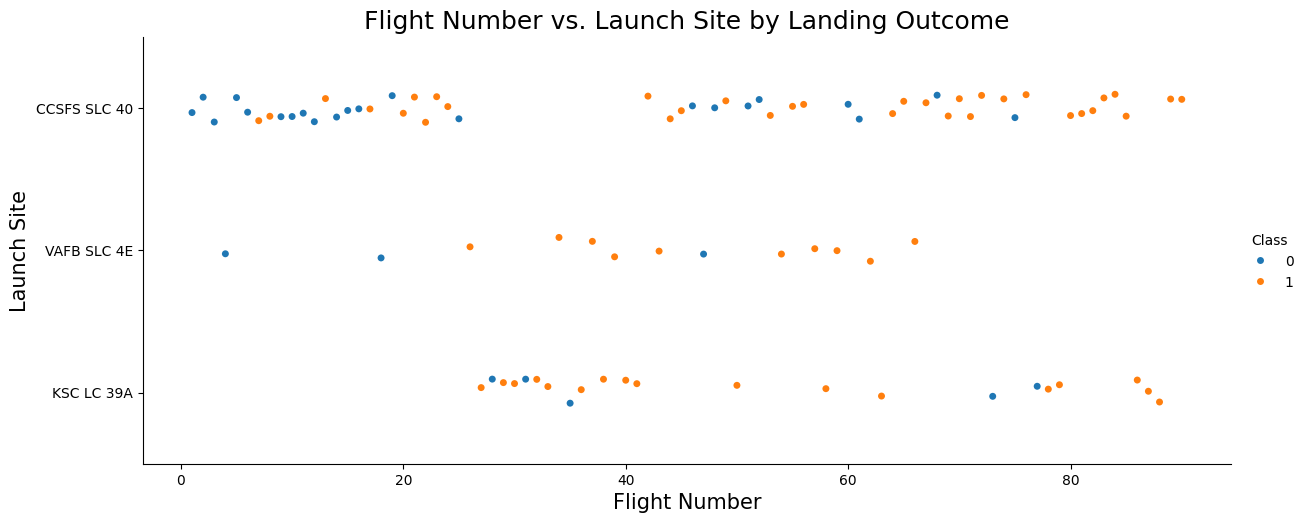

In [ ]:
sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=2.5, height=5)
plt.xlabel("Flight Number", fontsize=15)
plt.ylabel("Launch Site", fontsize=15)
plt.title("Flight Number vs. Launch Site by Landing Outcome", fontsize=18)
plt.show()

**Observation:** Early flights from all sites had lower success rates. As flight numbers increase (indicating more experience), success rates generally improve, especially for CCSFS SLC 40 and KSC LC 39A. VAFB SLC 4E shows a mixed pattern but has fewer launches overall in this dataset.

### Task 6: Visualize Relationship between Payload Mass and Launch Site

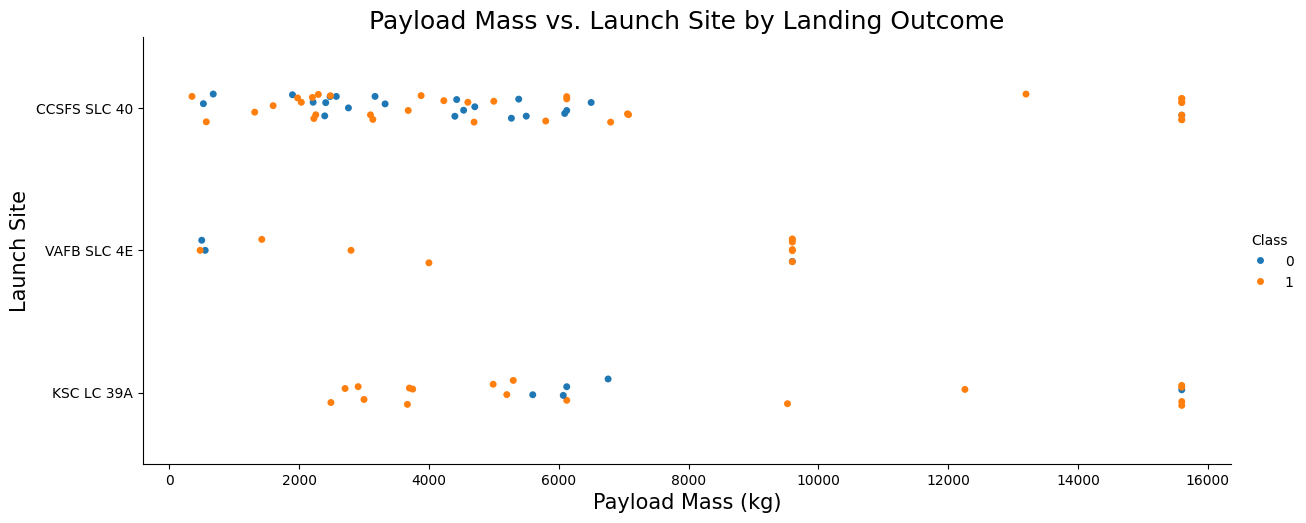

In [ ]:
sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=2.5, height=5)
plt.xlabel("Payload Mass (kg)", fontsize=15)
plt.ylabel("Launch Site", fontsize=15)
plt.title("Payload Mass vs. Launch Site by Landing Outcome", fontsize=18)
plt.show()

**Observation:** For the VAFB-SLC launch site, there are no rockets launched with heavy payload mass (greater than 10,000 kg). CCSFS SLC 40 and KSC LC 39A handle a wider range of payload masses, with successful landings occurring across various payload weights, though very heavy payloads might correlate with drone ship landings (ASDS) which can be more challenging.

### Task 7: Visualize the Success Rate of Each Orbit Type

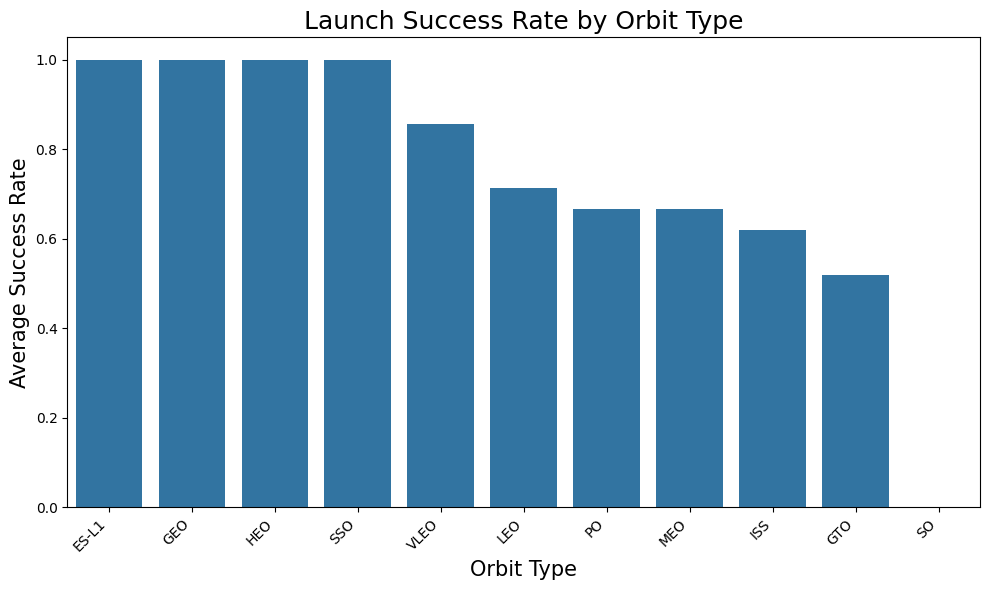

In [ ]:
orbit_success_rate = df.groupby('Orbit')['Class'].mean().reset_index().sort_values(by='Class', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Orbit', y='Class', data=orbit_success_rate)
plt.xlabel("Orbit Type", fontsize=15)
plt.ylabel("Average Success Rate", fontsize=15)
plt.title("Launch Success Rate by Orbit Type", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation:** Orbits like ES-L1, GEO, HEO, and SSO show high success rates in this dataset, though some might have few launches. GTO, a common and demanding orbit, has a moderate success rate. LEO and VLEO also show varied success.

### Task 8: Visualize the Relationship between Flight Number and Orbit Type

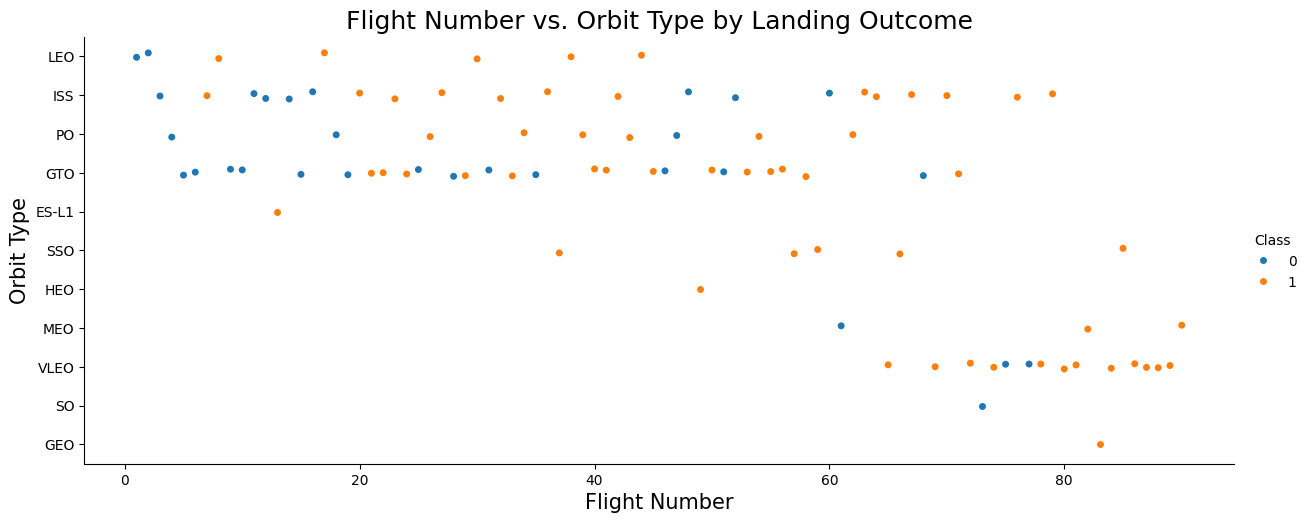

In [ ]:
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=2.5, height=5)
plt.ylabel("Orbit Type", fontsize=15)
plt.xlabel("Flight Number", fontsize=15)
plt.title("Flight Number vs. Orbit Type by Landing Outcome", fontsize=18)
plt.show()

**Observation:** For LEO and GTO orbits, later flight numbers tend to show more successful landings (Class 1). For other orbits with fewer data points, the trend is less clear.

### Task 9: Visualize the Relationship between Payload Mass and Orbit Type

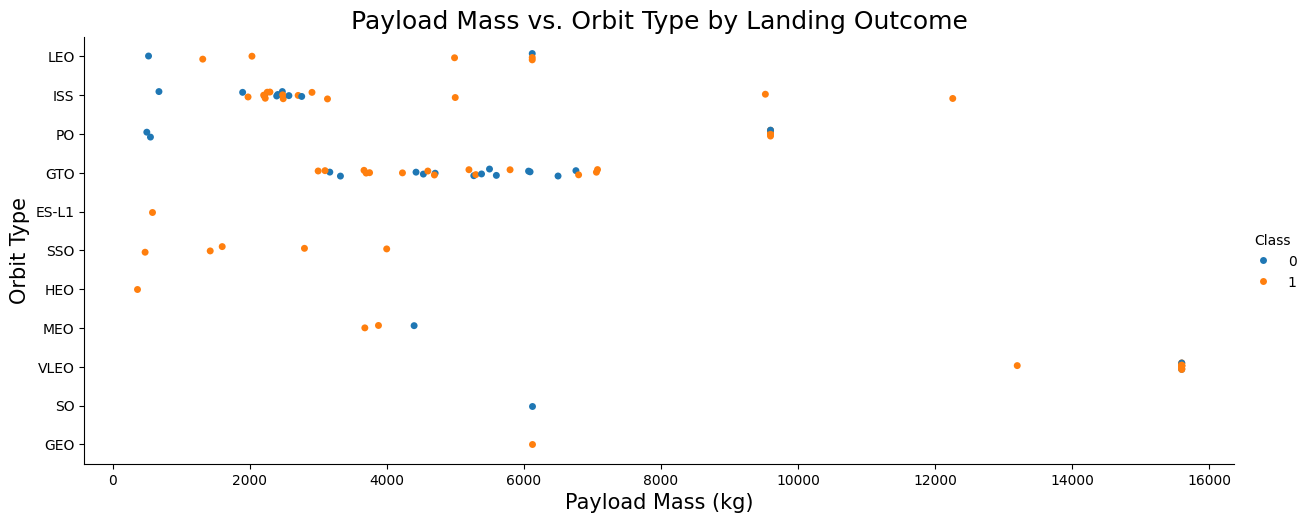

In [ ]:
sns.catplot(x="PayloadMass", y="Orbit", hue="Class", data=df, aspect=2.5, height=5)
plt.xlabel("Payload Mass (kg)", fontsize=15)
plt.ylabel("Orbit Type", fontsize=15)
plt.title("Payload Mass vs. Orbit Type by Landing Outcome", fontsize=18)
plt.show()

**Observation:** GTO launches often involve heavier payloads, and success rates vary. VLEO missions (often Starlink) tend to have very high payload masses (stack of satellites) and show good success rates. ISS missions have a moderate payload mass and good success rates. For orbits like HEO, ES-L1, and GEO with single launches, it's hard to draw conclusions about payload mass effects.

### Task 10: Visualize the Launch Success Yearly Trend

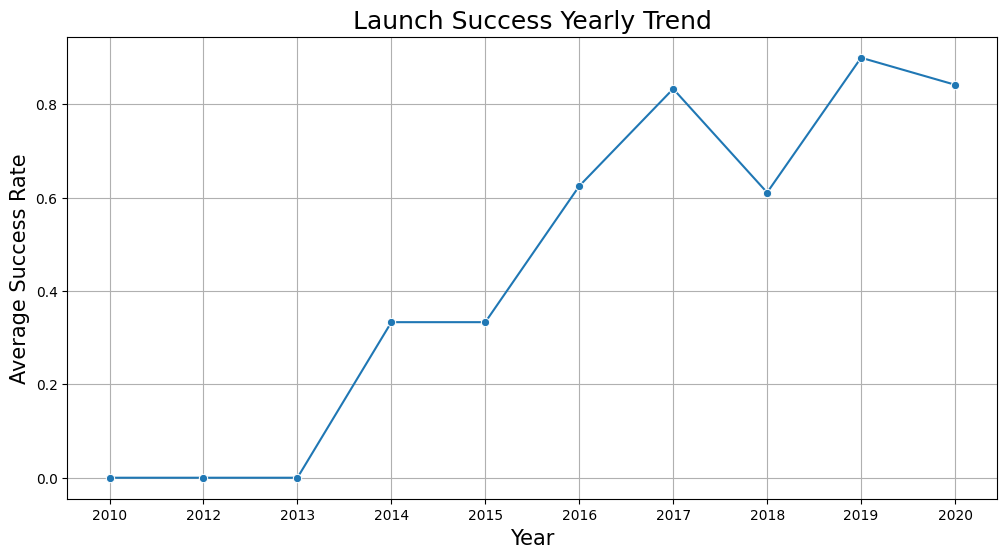

In [ ]:
# Create a 'Year' column from the 'Date' column (assuming 'Date' is in 'YYYY-MM-DD' string format)
df_yearly_trend = df.copy()
df_yearly_trend['Year'] = df_yearly_trend['Date'].apply(lambda x: x.split('-')[0])

# Calculate average success rate per year
yearly_success_rates = df_yearly_trend.groupby('Year')['Class'].mean().reset_index()

# Plot the yearly success rate trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_success_rates, x="Year", y="Class", marker='o')
plt.xlabel("Year", fontsize=15)
plt.ylabel("Average Success Rate", fontsize=15)
plt.title("Launch Success Yearly Trend", fontsize=18)
plt.grid(True)
plt.show()

**Observation:** The line plot clearly shows an upward trend in the average success rate of Falcon 9 first stage landings over the years, indicating improvements in technology and operational experience.

# 3. Feature Engineering

In this section, we will prepare our features for machine learning. This primarily involves selecting relevant features and applying one-hot encoding to categorical variables.

In [ ]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6123.547647,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### Task 1: Create dummy variables for categorical features

We will use one-hot encoding (via `pd.get_dummies`) to convert categorical columns (`Orbit`, `LaunchSite`, `LandingPad`, `Serial`) into numerical format. `GridFins`, `Reused`, and `Legs` are already boolean and can be treated as 0/1.

In [ ]:
# Apply one-hot encoding to specified categorical features
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCSFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6123.547647,1,False,False,False,1.0,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### Task 2: Cast all numeric columns to `float64`

To ensure all features are in a consistent numerical format for machine learning algorithms, we will cast the entire `features_one_hot` DataFrame to `float64`.

In [ ]:
features_one_hot = features_one_hot.astype('float64')
features_one_hot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 80 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   FlightNumber                         90 non-null     float64
 1   PayloadMass                          90 non-null     float64
 2   Flights                              90 non-null     float64
 3   GridFins                             90 non-null     float64
 4   Reused                               90 non-null     float64
 5   Legs                                 90 non-null     float64
 6   Block                                90 non-null     float64
 7   ReusedCount                          90 non-null     float64
 8   Orbit_ES-L1                          90 non-null     float64
 9   Orbit_GEO                            90 non-null     float64
 10  Orbit_GTO                            90 non-null     float64
 11  Orbit_HEO                         

The `features_one_hot` DataFrame is now ready. It contains only numerical data and can be used for training machine learning models in subsequent labs. The target variable `Class` (created during EDA) will be used alongside these features.

We can export this processed dataset for use in later stages.

In [ ]:
features_one_hot.to_csv('dataset_part_2.csv', index=False) # Saving the one-hot encoded features
df.to_csv('dataset_part_3.csv', index=False) # Saving the df with 'Class' column and 'Year' (if 'Date' was modified for plotting in EDA)

# 4. Machine Learning

## Modeling Workflow:

1. Load Data: Load the preprocessed features (`features_one_hot` from `dataset_part_2.csv`) and the target variable (`Class` from `df` (which was saved as `dataset_part_3.csv`)).

2. Define Features (X) and Target (Y): Separate your data into features (X) and the target variable (Y).

3. Split Data: Divide the data into training and testing sets.

4. Standardize Data: Scale the features using StandardScaler. This is important for algorithms like SVM and Logistic Regression.

5. Model Training & Hyperparameter Tuning:
- For each model (Logistic Regression, SVM, Decision Tree, and K-Nearest Neighbors KNN):
    - Define a pipeline that includes scaling (if not already done globally, but doing it in a pipeline is good practice, especially if cross-validating).
    - Define a parameter grid for hyperparameter tuning.
    - Use `GridSearchCV` to find the best hyperparameters for each model.
    - Train the model with the best found hyperparameters on the training data.

6. Model Evaluation:
- Evaluate each model on the test data.
- Calculate and report:
    - Accuracy
    - Jaccard Score
    - F1-Score
    - (For Logistic Regression, optionally LogLoss if probabilities are used)
- Plot the Confusion Matrix for each model.

7. Compare Models: Determine which model performs best based on the chosen metrics.

8. Report Results: Summarize the findings.



---

## 4.1 Load the Datasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, jaccard_score, f1_score, log_loss
import itertools # Confusion matrix plotting

In [ ]:
# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation='horizontal')
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

print("plot_confusion_matrix function defined.")

plot_confusion_matrix function defined.


## 4.2 Define Features (X) and Target (Y)

In [ ]:
X = pd.read_csv('dataset_part_2.csv')

df_with_class = pd.read_csv('dataset_part_3.csv')
Y = df_with_class['Class'].astype('int')

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (90, 80)
Y shape: (90,)


In [ ]:
X.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCSFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6123.547647,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4.3 Split Data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print('Train set:', X_train.shape, Y_train.shape)
print('Test set:', X_test.shape, Y_test.shape)

Train set: (72, 80) (72,)
Test set: (18, 80) (18,)


## 4.4 Standardize Data (Feature Scaling)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling complete.")

Feature scaling complete.


## 4.5 Model Traning & Testing

### Model 1: Logistic Regression

In [ ]:
print("--- Logistic Regression ---")
parameters_lr ={'C':[0.01,0.1,1],
             'penalty':['l2'], # l1 lasso l2 ridge
             'solver':['lbfgs']} # Note: 'liblinear' is also a good solver, especially for smaller datasets or l1 penalty

lr = LogisticRegression(random_state=1, max_iter=1000) # Increased max_iter for convergence
logreg_cv = GridSearchCV(lr, parameters_lr, cv=5)
logreg_cv.fit(X_train_scaled, Y_train)

print("Best parameters (Logistic Regression): ", logreg_cv.best_params_)
print("Accuracy on training data (Logistic Regression):", logreg_cv.best_score_)

--- Logistic Regression ---
Best parameters (Logistic Regression):  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy on training data (Logistic Regression): 0.82


In [ ]:
# Evaluate on test data
Y_pred_lr = logreg_cv.predict(X_test_scaled)
acc_lr = accuracy_score(Y_test, Y_pred_lr)
jaccard_lr = jaccard_score(Y_test, Y_pred_lr, pos_label=1) # Specify pos_label if not binary or for clarity
f1_lr = f1_score(Y_test, Y_pred_lr, pos_label=1)
# For log_loss, you need probability predictions
# Y_pred_proba_lr = logreg_cv.predict_proba(X_test_scaled)
# logloss_lr = log_loss(Y_test, Y_pred_proba_lr)

print("Accuracy on test data (Logistic Regression):", acc_lr)
print("Jaccard score (Logistic Regression):", jaccard_lr)
print("F1 score (Logistic Regression):", f1_lr)
# print("LogLoss (Logistic Regression):", logloss_lr)

Accuracy on test data (Logistic Regression): 0.8888888888888888
Jaccard score (Logistic Regression): 0.8666666666666667
F1 score (Logistic Regression): 0.9285714285714286


Confusion matrix, without normalization
[[ 3  1]
 [ 1 13]]


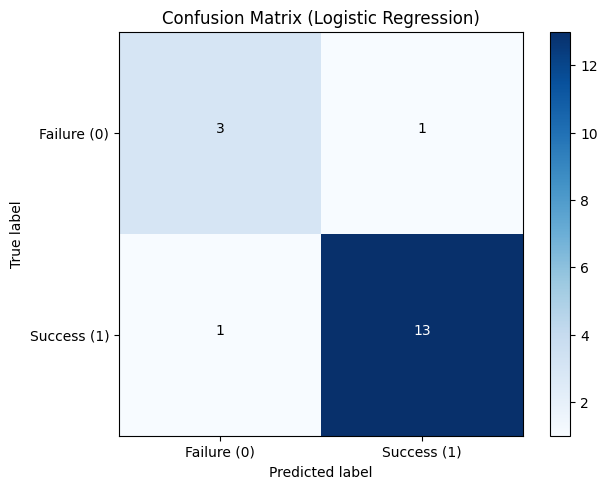


Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.93      0.93      0.93        14

    accuracy                           0.89        18
   macro avg       0.84      0.84      0.84        18
weighted avg       0.89      0.89      0.89        18



In [ ]:
# Confusion Matrix
cnf_matrix_lr = confusion_matrix(Y_test, Y_pred_lr, labels=[0,1])
np.set_printoptions(precision=2)
plt.figure()
plot_confusion_matrix(cnf_matrix_lr, classes=['Failure (0)','Success (1)'],normalize= False,  title='Confusion Matrix (Logistic Regression)')
print("\nClassification Report (Logistic Regression):\n", classification_report(Y_test, Y_pred_lr))

### Model 2: Support Vector Machine (SVM)

In [ ]:
print("--- Support Vector Machine (SVM) ---")
parameters_svm = {'kernel':('linear', 'rbf','poly','sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}
svm = SVC(random_state=1, probability=True) # probability=True for predict_proba if needed for other metrics later

svm_cv = GridSearchCV(svm, parameters_svm, cv=5)
svm_cv.fit(X_train_scaled, Y_train)

print("Best parameters (SVM): ", svm_cv.best_params_)
print("Accuracy on training data (SVM):", svm_cv.best_score_)

--- Support Vector Machine (SVM) ---
Best parameters (SVM):  {'C': np.float64(1.0), 'gamma': np.float64(1.0), 'kernel': 'sigmoid'}
Accuracy on training data (SVM): 0.8619047619047618


In [ ]:
# Evaluate on test data
Y_pred_svm = svm_cv.predict(X_test_scaled)
acc_svm = accuracy_score(Y_test, Y_pred_svm)
jaccard_svm = jaccard_score(Y_test, Y_pred_svm, pos_label=1)
f1_svm = f1_score(Y_test, Y_pred_svm, pos_label=1)

print("Accuracy on test data (SVM):", acc_svm)
print("Jaccard score (SVM):", jaccard_svm)
print("F1 score (SVM):", f1_svm)

Accuracy on test data (SVM): 0.6666666666666666
Jaccard score (SVM): 0.6
F1 score (SVM): 0.75


Confusion matrix, without normalization
[[3 1]
 [5 9]]


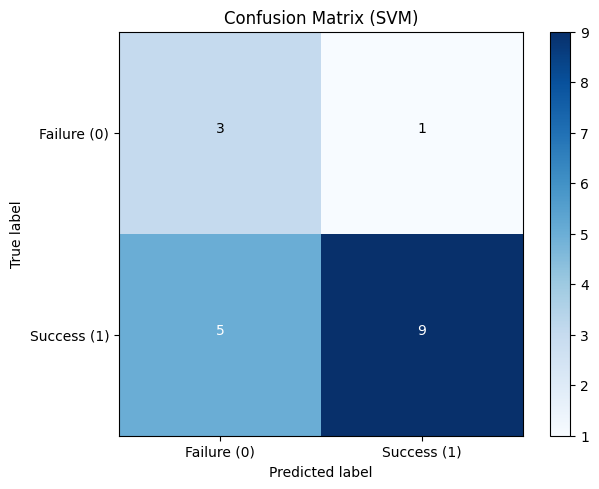


Classification Report (SVM):
               precision    recall  f1-score   support

           0       0.38      0.75      0.50         4
           1       0.90      0.64      0.75        14

    accuracy                           0.67        18
   macro avg       0.64      0.70      0.62        18
weighted avg       0.78      0.67      0.69        18



In [ ]:
# Confusion Matrix
cnf_matrix_svm = confusion_matrix(Y_test, Y_pred_svm, labels=[0,1])
plt.figure()
plot_confusion_matrix(cnf_matrix_svm, classes=['Failure (0)','Success (1)'],normalize= False,  title='Confusion Matrix (SVM)')
print("\nClassification Report (SVM):\n", classification_report(Y_test, Y_pred_svm))

### Model 3: Decision Tree

In [ ]:
print("--- Decision Tree ---")
parameters_tree = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['sqrt', 'log2', None], # Changed 'auto' to None or sqrt/log2
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier(random_state=1)
tree_cv = GridSearchCV(tree, parameters_tree, cv=5)
tree_cv.fit(X_train_scaled, Y_train) # Scaled data might not be strictly necessary for trees, but won't hurt

print("Best parameters (Decision Tree): ",tree_cv.best_params_)
print("Accuracy on training data (Decision Tree):", tree_cv.best_score_)

--- Decision Tree ---
Best parameters (Decision Tree):  {'criterion': 'gini', 'max_depth': 2, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
Accuracy on training data (Decision Tree): 0.8619047619047618


In [ ]:
# Evaluate on test data
Y_pred_tree = tree_cv.predict(X_test_scaled)
acc_tree = accuracy_score(Y_test, Y_pred_tree)
jaccard_tree = jaccard_score(Y_test, Y_pred_tree, pos_label=1)
f1_tree = f1_score(Y_test, Y_pred_tree, pos_label=1)

print("Accuracy on test data (Decision Tree):", acc_tree)
print("Jaccard score (Decision Tree):", jaccard_tree)
print("F1 score (Decision Tree):", f1_tree)

Accuracy on test data (Decision Tree): 0.8888888888888888
Jaccard score (Decision Tree): 0.8571428571428571
F1 score (Decision Tree): 0.9230769230769231


Confusion matrix, without normalization
[[ 4  0]
 [ 2 12]]


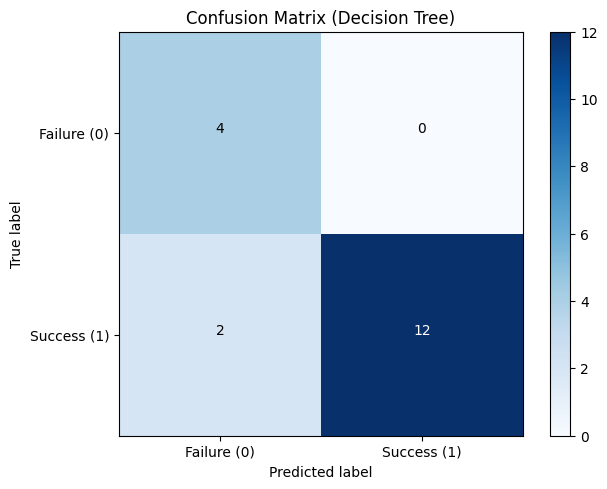


Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       1.00      0.86      0.92        14

    accuracy                           0.89        18
   macro avg       0.83      0.93      0.86        18
weighted avg       0.93      0.89      0.90        18



In [ ]:
# Confusion Matrix
cnf_matrix_tree = confusion_matrix(Y_test, Y_pred_tree, labels=[0,1])
plt.figure()
plot_confusion_matrix(cnf_matrix_tree, classes=['Failure (0)','Success (1)'],normalize= False,  title='Confusion Matrix (Decision Tree)')
print("\nClassification Report (Decision Tree):\n", classification_report(Y_test, Y_pred_tree))

### Model 4: K-Nearest Neighbors (KNN)

In [ ]:
print("--- K-Nearest Neighbors (KNN) ---")
parameters_knn = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv=5)
knn_cv.fit(X_train_scaled, Y_train)

print("Best parameters (KNN): ", knn_cv.best_params_)
print("Accuracy on training data (KNN):", knn_cv.best_score_)

--- K-Nearest Neighbors (KNN) ---
Best parameters (KNN):  {'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}
Accuracy on training data (KNN): 0.819047619047619


In [ ]:
# Evaluate on test data
Y_pred_knn = knn_cv.predict(X_test_scaled)
acc_knn = accuracy_score(Y_test, Y_pred_knn)
jaccard_knn = jaccard_score(Y_test, Y_pred_knn, pos_label=1)
f1_knn = f1_score(Y_test, Y_pred_knn, pos_label=1)

print("Accuracy on test data (KNN):", acc_knn)
print("Jaccard score (KNN):", jaccard_knn)
print("F1 score (KNN):", f1_knn)

Accuracy on test data (KNN): 0.9444444444444444
Jaccard score (KNN): 0.9333333333333333
F1 score (KNN): 0.9655172413793104


Confusion matrix, without normalization
[[ 3  1]
 [ 0 14]]


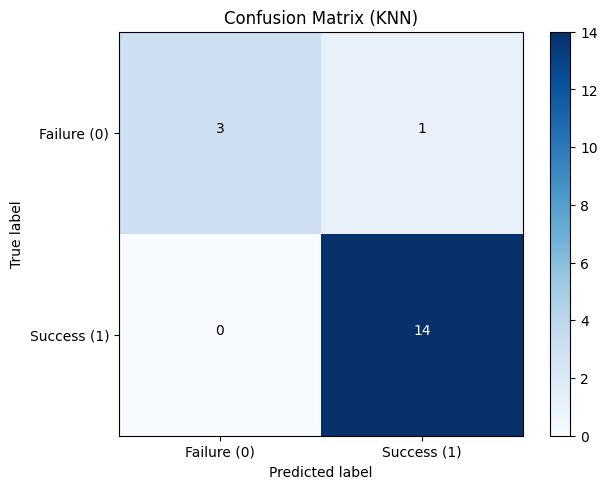


Classification Report (KNN):
               precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.93      1.00      0.97        14

    accuracy                           0.94        18
   macro avg       0.97      0.88      0.91        18
weighted avg       0.95      0.94      0.94        18



In [ ]:
# Confusion Matrix
cnf_matrix_knn = confusion_matrix(Y_test, Y_pred_knn, labels=[0,1])
plt.figure()
plot_confusion_matrix(cnf_matrix_knn, classes=['Failure (0)','Success (1)'],normalize= False,  title='Confusion Matrix (KNN)')
print("\nClassification Report (KNN):\n", classification_report(Y_test, Y_pred_knn))

## 4.6 Model Comparison

In [ ]:
# Create a dictionary to store the test accuracies
model_accuracies = {
    'Logistic Regression': acc_lr,
    'SVM': acc_svm,
    'Decision Tree': acc_tree,
    'KNN': acc_knn
}

model_jaccard = {
    'Logistic Regression': jaccard_lr,
    'SVM': jaccard_svm,
    'Decision Tree': jaccard_tree,
    'KNN': jaccard_knn
}

model_f1 = {
    'Logistic Regression': f1_lr,
    'SVM': f1_svm,
    'Decision Tree': f1_tree,
    'KNN': f1_knn
}

In [ ]:
# Create a DataFrame for better visualization
report_df = pd.DataFrame({
    'Algorithm': list(model_accuracies.keys()),
    'Accuracy': list(model_accuracies.values()),
    'Jaccard': list(model_jaccard.values()),
    'F1-score': list(model_f1.values())
})

print("\n--- Model Performance Summary on Test Data ---")
print(report_df)


--- Model Performance Summary on Test Data ---
             Algorithm  Accuracy   Jaccard  F1-score
0  Logistic Regression  0.888889  0.866667  0.928571
1                  SVM  0.666667  0.600000  0.750000
2        Decision Tree  0.888889  0.857143  0.923077
3                  KNN  0.944444  0.933333  0.965517


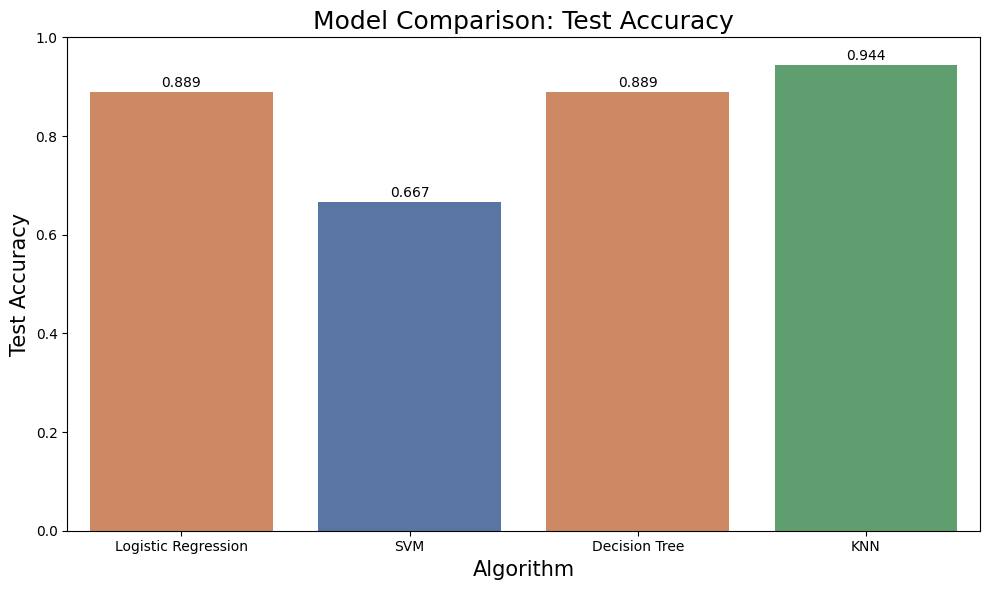

In [ ]:
# Plotting the accuracies for visual comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Algorithm', y='Accuracy', data=report_df, hue='Accuracy', palette='deep', legend=False)
plt.xlabel("Algorithm", fontsize=15)
plt.ylabel("Test Accuracy", fontsize=15)
plt.title("Model Comparison: Test Accuracy", fontsize=18)
plt.xticks(rotation='horizontal', ha='center')
plt.ylim(0, 1.0) # Set y-axis limits for better comparison if accuracies are high
for index, row in report_df.iterrows():
    plt.text(row.name, row.Accuracy + 0.01, f"{row.Accuracy:.3f}", color='black', ha="center")
plt.tight_layout()
plt.show()

In [ ]:
# Finding the best model
best_model_name = report_df.loc[report_df['Accuracy'].idxmax()]['Algorithm']
best_model_accuracy = report_df['Accuracy'].max()

print(f"The best performing model on the test data is: {best_model_name} with an accuracy of {best_model_accuracy:.3f}")

The best performing model on the test data is: KNN with an accuracy of 0.944


**Notes:**

1. Standardization:
- `StandardScaler` standardizes features by removing the mean and scaling to unit variance.
- It's crucial to `fit` the scaler `only on the training data` (X_train_scaled) and then use that same fitted scaler to `transform both` the training and test data (X_test_scaled). This prevents data leakage from the test set.

2. Model Blocks (Logistic Regression, SVM, Decision Tree, KNN):
- Parameters: A dictionary `parameters_...` defines the grid of hyperparameters to search for each model.
- GridSearchCV:
    - `cv=5` means 5-fold cross-validation will be used during the grid search.
    - `GridSearchCV` will try all combinations of parameters and find the best ones based on cross-validated accuracy (by default).
    - `logreg_cv.fit(X_train_scaled, Y_train)`: The grid search is performed on the scaled training data.
    - `logreg_cv.best_params_`: Shows the best combination of hyperparameters found.
    - `logreg_cv.best_score_`: Shows the mean cross-validated score of the best_estimator on the training data.
- Evaluation:
    - `Y_pred_... = ..._cv.predict(X_test_scaled)`: Predictions are made on the scaled test data using the best model found by GridSearchCV.
    - Metrics (accuracy_score, jaccard_score, f1_score, confusion_matrix, classification_report) are calculated by comparing Y_test (true labels) with Y_pred_... (predicted labels).
    - `pos_label=1` is specified for Jaccard and F1 scores, assuming '1' (Success) is the positive class you are most interested in for these metrics. Adjust if '0' is your positive class.
- Confusion Matrix: The `plot_confusion_matrix` function is called to visualize the results.







---

